# Repeated cold-solute holdouts for the GINE comparison

The cold-solute result in the representation study rests on a single held-out
solute set: GINE 0.9667 against the descriptor MLP 0.8825, despite matching it
on the random split.

A single chemistry partition has already proved unreliable on this axis — a
within-partition bootstrap gave `P = 0.998` for a conclusion that reversed under
repeated holdouts. The question here is whether the GINE penalty persists when
the identity of the held-out solutes changes.

Same five partitions as the earlier repeated-holdout experiment (`group_split`
over solutes, split seeds 11/22/33/44/55). All four models are trained on
identical rows within each partition. Two model seeds rather than three: the
partition is the unit of replication, and seed spread on this split (~0.018) is
small against the effect (~0.084).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "scripts"))
RES = ROOT / "results"

runs = pd.read_csv(RES / "metrics_coldsol_repeat.csv")
runs = runs.drop_duplicates(["model", "split_seed", "model_seed"], keep="last")
print(f"runs: {len(runs)}")
print(runs.groupby(["split_seed", "model"]).size().unstack("model").to_string())

runs: 40
model       A_GINE  A_MLP  Bc_GINE  Bc_MLP
split_seed                                
11               2      2        2       2
22               2      2        2       2
33               2      2        2       2
44               2      2        2       2
55               2      2        2       2


## Per-partition results

Each cell is the mean over the 2 model seeds. `delta_repr` is the
representation gap **within** a head — positive means GINE is worse.

In [2]:
mean = runs.groupby(["split_seed", "model"])["test_rmse"].mean().unstack("model")
mean["delta_repr direct"] = mean["A_GINE"] - mean["A_MLP"]
mean["delta_repr physics"] = mean["Bc_GINE"] - mean["Bc_MLP"]
mean.round(4)[["A_MLP", "A_GINE", "delta_repr direct",
               "Bc_MLP", "Bc_GINE", "delta_repr physics"]]

model,A_MLP,A_GINE,delta_repr direct,Bc_MLP,Bc_GINE,delta_repr physics
split_seed,,,,,,
11,0.8566,0.9270,0.0704,0.8837,0.9126,0.0289
22,1.0295,0.9701,-0.0594,1.0167,1.0005,-0.0163
33,0.8221,0.8708,0.0487,0.7957,0.8469,0.0512
44,0.9156,1.0042,0.0886,0.9129,0.9863,0.0734
55,0.8601,0.9063,0.0462,0.8622,0.8867,0.0245


## Summary across partitions

In [3]:
summary = []
for head, mlp, gine in [("direct (A)", "A_MLP", "A_GINE"),
                        ("physics (Bc)", "Bc_MLP", "Bc_GINE")]:
    d = mean[gine] - mean[mlp]
    summary.append({
        "head": head,
        "mean delta (GINE - MLP)": round(d.mean(), 4),
        "std across partitions": round(d.std(), 4),
        "GINE better in": f"{int((d < 0).sum())}/{len(d)}",
        "range": f"[{d.min():+.4f}, {d.max():+.4f}]",
    })
pd.DataFrame(summary).set_index("head")

,mean delta (GINE - MLP),std across partitions,GINE better in,range
head,,,,
direct (A),0.0389,0.0576,1/5,"[-0.0594, +0.0886]"
physics (Bc),0.0323,0.0335,1/5,"[-0.0163, +0.0734]"


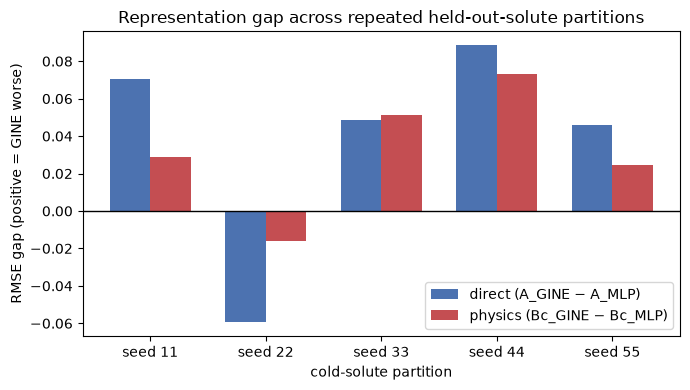

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(mean))
w = 0.35
ax.bar(x - w/2, (mean["A_GINE"] - mean["A_MLP"]), w, label="direct (A_GINE − A_MLP)", color="#4C72B0")
ax.bar(x + w/2, (mean["Bc_GINE"] - mean["Bc_MLP"]), w, label="physics (Bc_GINE − Bc_MLP)", color="#C44E52")
ax.axhline(0, color="k", lw=1)
ax.set_xticks(x); ax.set_xticklabels([f"seed {s}" for s in mean.index])
ax.set_xlabel("cold-solute partition"); ax.set_ylabel("RMSE gap (positive = GINE worse)")
ax.set_title("Representation gap across repeated held-out-solute partitions")
ax.legend()
fig.tight_layout(); fig.savefig(RES / "fig11_repr_gap.png", dpi=140)
plt.show()

## Intercept diagnostic across partitions

This matters more than another slope table. Under cold-solute the intercept
term dominates total error by ~14x (finding 7), so `|a_pred - a_true|` is the
quantity the representation hypothesis actually lives or dies on.

For each partition we fit the empirical Van't Hoff line on each held-out pair's
own test rows to get `a_true`, then compare against what each physics model
predicted from chemistry alone.

In [5]:
T_REF = 298.15
feats = np.load(RES / "features.npz", allow_pickle=True)
T_arr = feats["T"].astype(np.float64)
y_all = feats["y"].astype(np.float64)
pair_id = feats["pair_id"]
z_all = 1.0 / T_REF - 1.0 / T_arr
PREDS = RES / "preds_coldsol_repeat"


def empirical_a(rows_idx):
    # Per-pair OLS intercept at T_ref, fitted on the pair's own test rows.
    df = pd.DataFrame({"pair_id": pair_id[rows_idx], "z": z_all[rows_idx], "y": y_all[rows_idx]})
    out = {}
    for pid, g in df.groupby("pair_id"):
        if len(g) < 3 or g["z"].nunique() < 3:
            continue
        zc = g["z"] - g["z"].mean()
        den = float((zc ** 2).sum())
        if den <= 0:
            continue
        b = float((zc * (g["y"] - g["y"].mean())).sum() / den)
        out[pid] = float(g["y"].mean() - b * g["z"].mean())
    return pd.Series(out, name="a_true")

In [6]:
SPLIT_SEEDS = sorted(runs.split_seed.unique())
MODEL_SEEDS = sorted(runs.model_seed.unique())

rows_out = []
for ss in SPLIT_SEEDS:
    ref = np.load(PREDS / f"preds_Bc_MLP_ss{ss}_seed{MODEL_SEEDS[0]}.npz", allow_pickle=True)
    a_true = empirical_a(ref["test_idx"])
    for tag in ["Bc_MLP", "Bc_GINE"]:
        frames = []
        for ms in MODEL_SEEDS:
            f = PREDS / f"preds_{tag}_ss{ss}_seed{ms}.npz"
            if not f.exists():
                continue
            d = np.load(f, allow_pickle=True)
            frames.append(pd.DataFrame({"pair_id": d["pair_id"], "a": d["slope_a"]})
                          .groupby("pair_id")["a"].first())
        if not frames:
            continue
        a_pred = pd.concat(frames, axis=1).mean(axis=1)
        j = pd.concat([a_true, a_pred.rename("a_pred")], axis=1).dropna()
        rows_out.append({"split_seed": ss, "model": tag, "pairs": len(j),
                         "median |a_pred - a_true|": round(float((j.a_pred - j.a_true).abs().median()), 4)})

icept = pd.DataFrame(rows_out).pivot(index="split_seed", columns="model",
                                     values="median |a_pred - a_true|")
icept["delta (GINE - MLP)"] = icept["Bc_GINE"] - icept["Bc_MLP"]
icept.round(4)

model,Bc_GINE,Bc_MLP,delta (GINE - MLP)
split_seed,,,
11,0.5074,0.5306,-0.0232
22,0.6350,0.5599,0.0751
33,0.5135,0.4952,0.0183
44,0.5701,0.5504,0.0197
55,0.5470,0.4518,0.0952


In [7]:
d = icept["delta (GINE - MLP)"]
print(f"intercept-error gap (GINE - MLP) across {len(d)} partitions:")
print(f"  mean  {d.mean():+.4f}")
print(f"  std   {d.std():.4f}")
print(f"  range [{d.min():+.4f}, {d.max():+.4f}]")
print(f"  GINE better in {(d < 0).sum()}/{len(d)} partitions")

intercept-error gap (GINE - MLP) across 5 partitions:
  mean  +0.0370
  std   0.0477
  range [-0.0232, +0.0952]
  GINE better in 1/5 partitions


## Across-partition interval

Five partitions is few, so alongside mean/std it is worth asking whether the gap
is resolved at all. The partition is the sampling unit, so a one-sample t
interval over the five per-partition gaps is the appropriate simple test.

In [8]:
from scipy import stats

def interval(v, label):
    v = np.asarray(v); n = len(v)
    se = v.std(ddof=1) / np.sqrt(n)
    t = stats.t.ppf(0.975, n - 1)
    p = stats.ttest_1samp(v, 0).pvalue
    print(f"{label:16s} mean {v.mean():+.4f}   95% CI [{v.mean()-t*se:+.4f}, {v.mean()+t*se:+.4f}]   p={p:.3f}")

interval(mean["A_GINE"] - mean["A_MLP"], "direct (A)")
interval(mean["Bc_GINE"] - mean["Bc_MLP"], "physics (Bc)")
print()
print(f"notebook 10, single partition (direct head): +0.0842")
print(f"repeated-holdout mean                      : {(mean['A_GINE']-mean['A_MLP']).mean():+.4f}"
      f"   -> the single partition overstated it by {0.0842/(mean['A_GINE']-mean['A_MLP']).mean():.1f}x")

direct (A)       mean +0.0389   95% CI [-0.0326, +0.1104]   p=0.206
physics (Bc)     mean +0.0323   95% CI [-0.0092, +0.0739]   p=0.097

notebook 10, single partition (direct head): +0.0842
repeated-holdout mean                      : +0.0389   -> the single partition overstated it by 2.2x


## Conclusion

GINE is worse on 4 of 5 partitions, on both heads, and the intercept diagnostic
agrees on the same 4. The direction is consistent.

| measure | mean gap (GINE − MLP) | std | GINE better |
|---|---:|---:|---:|
| RMSE, direct head | +0.0389 | 0.0576 | 1/5 |
| RMSE, physics head | +0.0323 | 0.0335 | 1/5 |
| median \|a_pred − a_true\| | +0.0370 | 0.0477 | 1/5 |

The magnitude does not hold up. A single partition gave +0.0842; the
repeated-holdout mean is +0.0389, so the single partition overstated the gap by
a factor of 2.2. With five partitions none of the intervals excludes zero
(direct [−0.033, +0.110], p = 0.21; physics [−0.009, +0.074], p = 0.10;
intercept [−0.022, +0.096], p = 0.16), and partition 22 reverses.

Representation choice under chemistry shift is therefore partition-dependent,
with a consistent lean toward the graph encoder transferring worse to unseen
solutes. The effect is not resolved at n = 5, and the size of it should not be
quoted from a single partition. This concerns one untuned GINE configuration on
one dataset, not graph networks generally.

The cold-pair result is unaffected: the learned encoder helps on unseen
combinations of molecules it has already seen.